In [39]:
import pandas as pd

hydrazide_df = pd.read_csv("../data/clean_hydrazides.csv")

In [40]:
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd

# substructure query to detect a free hydrazide
hydrazide_q = Chem.MolFromSmarts('[CX3:1](=[OX1])[NX3;H1:2][NX3;H2:3]')

# reaction: hydrazide -> 3-R-5,6-dimethyl-1,2,4-triazine
rxn = AllChem.ReactionFromSmarts(
    '[CX3:1](=[OX1])[NX3;H1:2][NX3;H2:3]>>[c:1]1[n:2][n:3]c(C)c(C)n1'
)

def to_triazine(mol):
    """Cyclize every hydrazide group present (handles mono- and di-hydrazides)."""
    working = mol
    for _ in range(5):  # safety cap
        if not working.HasSubstructMatch(hydrazide_q):
            break
        prods = rxn.RunReactants((working,))
        if not prods:
            break
        new_mol = prods[0][0]
        try:
            Chem.SanitizeMol(new_mol)
        except Exception:
            break
        working = new_mol
    return working

#df = pd.read_csv('hydrazides.csv')   # needs a 'SMILES' column
out = []
for smi in hydrazide_df['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    if mol is None or not mol.HasSubstructMatch(hydrazide_q):
        out.append(None)
        continue
    prod = to_triazine(mol)
    out.append(Chem.MolToSmiles(prod))

hydrazide_df['Triazine_SMILES'] = out
#df.to_csv('triazine_library.csv', index=False)

print(hydrazide_df['Triazine_SMILES'] )

0                                   Cc1nnc(-c2ccncc2)nc1C
1                                   Cc1nnc(-c2ccccc2)nc1C
2                                Cc1nnc(-c2ccc(N)cc2)nc1C
3                               Cc1nnc(-c2ccc(Br)cc2)nc1C
4                             COc1ccc(-c2nnc(C)c(C)n2)cc1
                              ...                        
5966        COC(Cc1nnc(C)c(C)n1)=C1Nc2c(C)cc(F)cc2NC1(C)C
5967        COCC(=C1Nc2c(C)cc(F)cc2NC1(C)C)c1nnc(C)c(C)n1
5968              Cc1ccc(-c2nnc(C)c(C)n2)c(C(=O)C(F)F)c1F
5969    Cc1nnc(-c2ccc(CN(c3cccc(Cl)c3)S(=O)(=O)C(Cl)Cl...
5970    Cc1nnc(-c2ccc(CN(C=O)CCC(C)Cc3cccc(F)c3)c(F)c2...
Name: Triazine_SMILES, Length: 5971, dtype: str


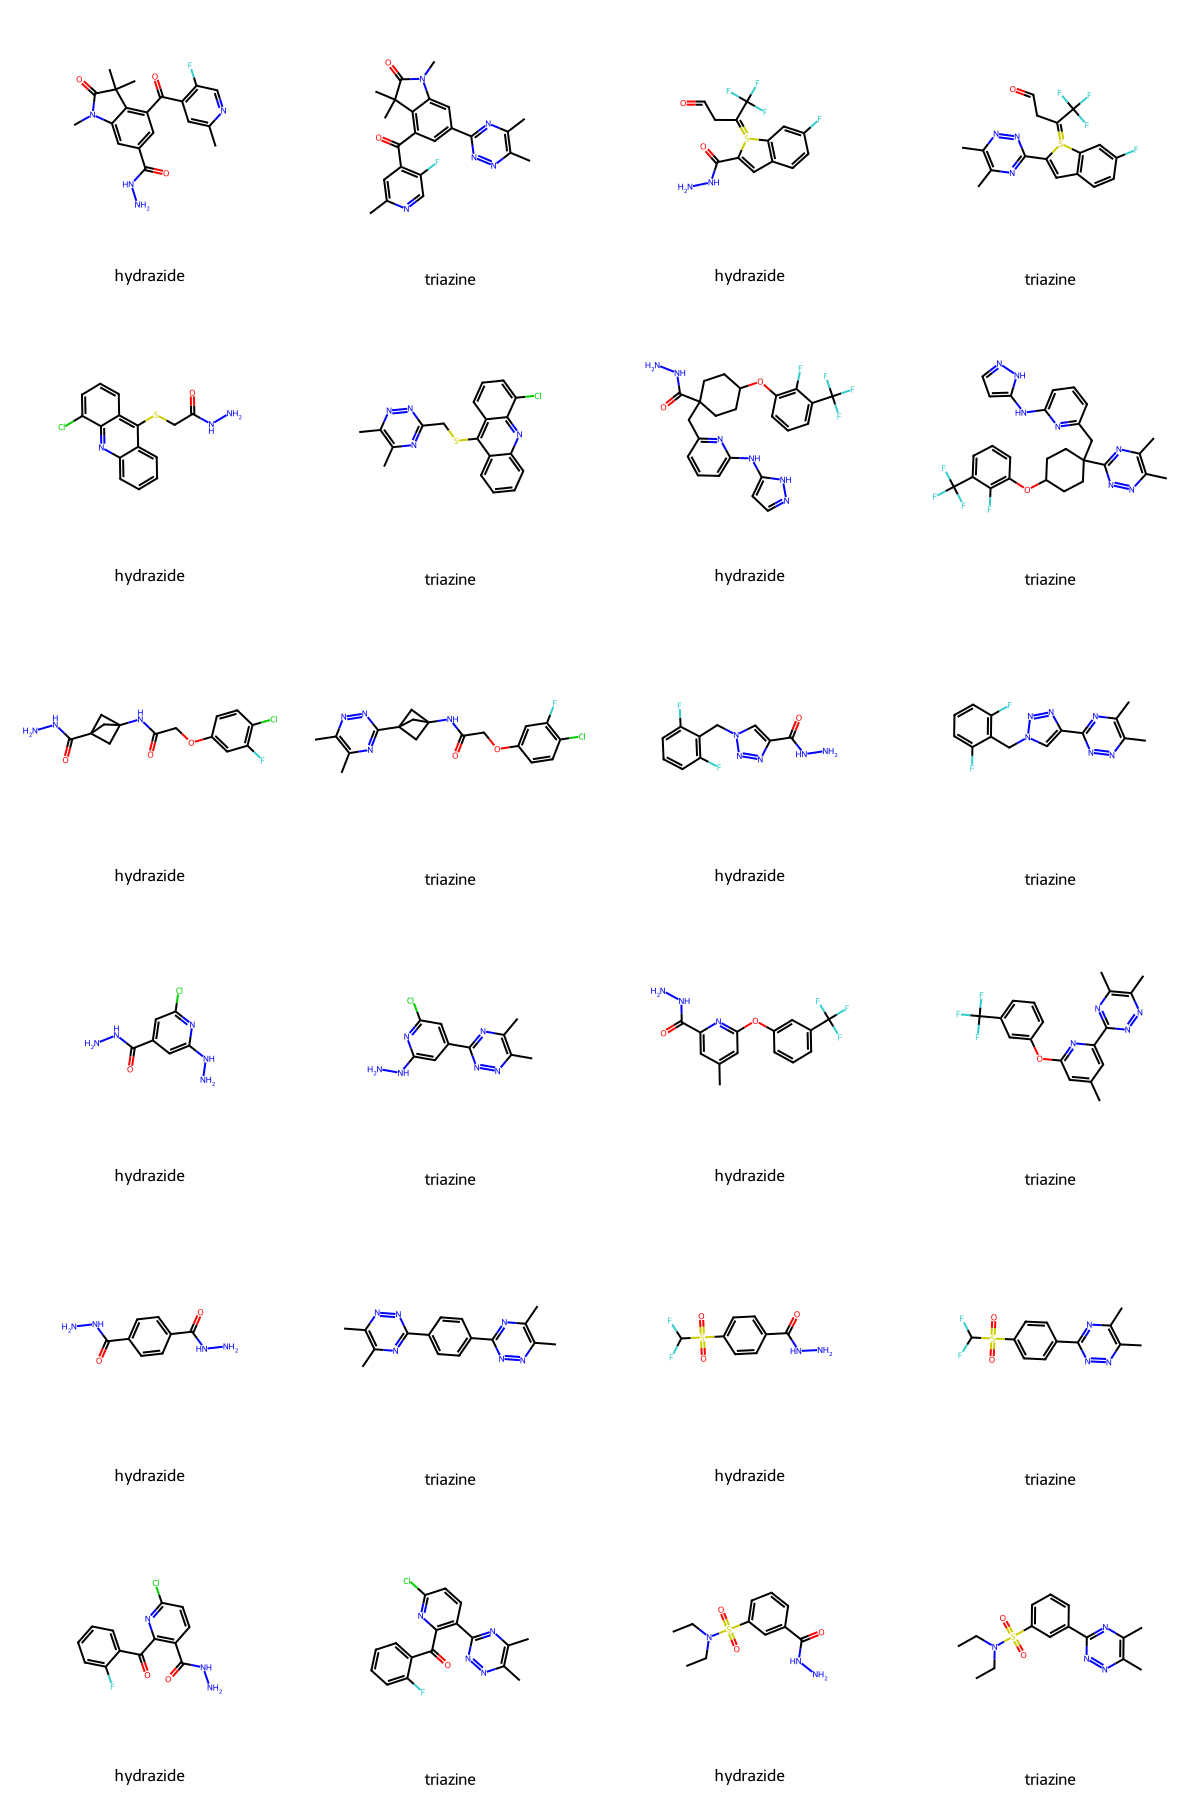

In [41]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
import random

# pick a random sample to inspect
sample_df = hydrazide_df.dropna(subset=['Triazine_SMILES']).sample(12, random_state=42)

mols = []
legends = []

for _, row in sample_df.iterrows():
    hydrazide_mol = Chem.MolFromSmiles(row['SMILES'])
    triazine_mol  = Chem.MolFromSmiles(row['Triazine_SMILES'])
    mols.extend([hydrazide_mol, triazine_mol])
    legends.extend(['hydrazide', 'triazine'])

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 300),
    legends=legends,
    useSVG=False
)
#img.save('qc_grid.png')
img

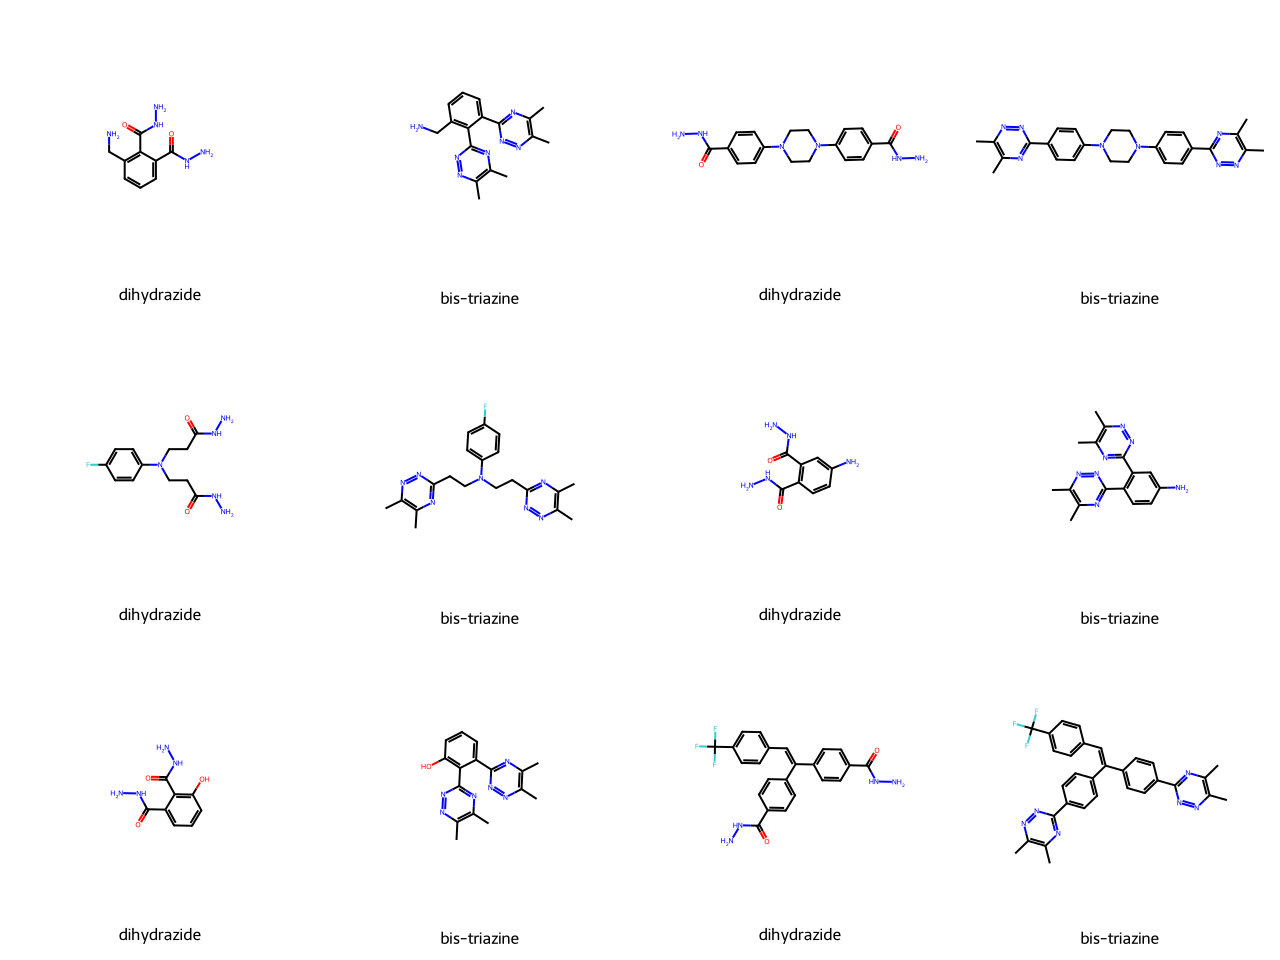

In [42]:
dihydrazide_q = Chem.MolFromSmarts('[CX3](=[OX1])[NX3;H1][NX3;H2]')

def count_hydrazide_groups(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return 0
    return len(mol.GetSubstructMatches(dihydrazide_q))

hydrazide_df['n_hydrazide_groups'] = hydrazide_df['SMILES'].apply(count_hydrazide_groups)
di_sample = hydrazide_df[hydrazide_df['n_hydrazide_groups'] == 2].dropna(subset=['Triazine_SMILES']).sample(6, random_state=1)

mols, legends = [], []
for _, row in di_sample.iterrows():
    mols.append(Chem.MolFromSmiles(row['SMILES']))
    mols.append(Chem.MolFromSmiles(row['Triazine_SMILES']))
    legends += ['dihydrazide', 'bis-triazine']

Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(320,320), legends=legends)

In [43]:
import pandas as pd

# Build a separate triazine dataframe
triazine_df = hydrazide_df.loc[hydrazide_df['Triazine_SMILES'].notna(), ['Triazine_SMILES']].copy()
triazine_df = triazine_df.rename(columns={'Triazine_SMILES': 'SMILES'})
triazine_df = triazine_df.reset_index(drop=True)
triazine_df.insert(0, 'Triazine_ID', ['TRZ' + str(i+1).zfill(5) for i in range(len(triazine_df))])

# if you want to retain a link back to the original hydrazide (recommended for traceability),
# carry over an ID column instead of dropping the source completely
if 'Hydrazide_ID' in hydrazide_df.columns:
    triazine_df['Source_Hydrazide_ID'] = hydrazide_df.loc[hydrazide_df['Triazine_SMILES'].notna(), 'Hydrazide_ID'].reset_index(drop=True)
else:
    triazine_df['Source_Hydrazide_SMILES'] = hydrazide_df.loc[hydrazide_df['Triazine_SMILES'].notna(), 'SMILES'].reset_index(drop=True)

triazine_df.to_csv('../results/virtual_triazine_library.csv', index=False)
triazine_df.head()

,Triazine_ID,SMILES,Source_Hydrazide_SMILES
0,TRZ00001,Cc1nnc(-c2ccncc2)nc1C,C1=CN=CC=C1C(=O)NN
1,TRZ00002,Cc1nnc(-c2ccccc2)nc1C,C1=CC=C(C=C1)C(=O)NN
2,TRZ00003,Cc1nnc(-c2ccc(N)cc2)nc1C,C1=CC(=CC=C1C(=O)NN)N
3,TRZ00004,Cc1nnc(-c2ccc(Br)cc2)nc1C,C1=CC(=CC=C1C(=O)NN)Br
4,TRZ00005,COc1ccc(-c2nnc(C)c(C)n2)cc1,COC1=CC=C(C=C1)C(=O)NN


In [44]:
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

descriptor_list = []

for index, row in triazine_df.iterrows():
    Triazine_ID = row["Triazine_ID"]
    smiles = row["SMILES"]

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        print("Invalid SMILES:", Triazine_ID, smiles)
        continue

    descriptor_data = {
        "Triazine_ID": Triazine_ID,
        "SMILES": smiles,
        "MolWt": round(Descriptors.MolWt(mol), 2),
        "LogP": round(Crippen.MolLogP(mol), 2),
        "TPSA": round(rdMolDescriptors.CalcTPSA(mol), 2),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "AromaticRings": Lipinski.NumAromaticRings(mol),
    }

    descriptor_list.append(descriptor_data)

triazine_descriptor_df = pd.DataFrame(descriptor_list)
triazine_descriptor_df.head(20)


,Triazine_ID,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings
0,TRZ00001,Cc1nnc(-c2ccncc2)nc1C,186.22,1.55,51.56,0,4,1,2
1,TRZ00002,Cc1nnc(-c2ccccc2)nc1C,185.23,2.16,38.67,0,3,1,2
2,TRZ00003,Cc1nnc(-c2ccc(N)cc2)nc1C,200.24,1.74,64.69,1,4,1,2
3,TRZ00004,Cc1nnc(-c2ccc(Br)cc2)nc1C,264.13,2.92,38.67,0,3,1,2
4,TRZ00005,COc1ccc(-c2nnc(C)c(C)n2)cc1,215.26,2.16,47.90,0,4,2,2
5,TRZ00006,Cc1nnc(-c2ccccc2O)nc1C,201.23,1.86,58.90,1,4,1,2
6,TRZ00007,Cc1nnc(-c2ccc(O)cc2)nc1C,201.23,1.86,58.90,1,4,1,2
7,TRZ00008,Cc1nnc(CN2C(=O)CN=C(c3ccccc3)c3cc(Br)ccc32)nc1C,436.31,3.64,71.34,0,5,3,3
8,TRZ00009,Cc1nnc(CP(=O)(c2ccccc2)c2ccccc2)nc1C,323.34,3.00,55.74,0,4,4,3
9,TRZ00010,COc1ccccc1-c1nnc(C)c(C)n1,215.26,2.16,47.90,0,4,2,2


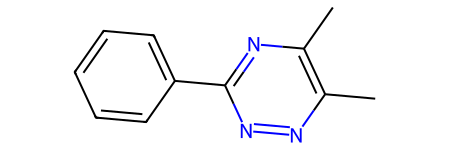

In [45]:
from IPython.display import display

smiles = "Cc1nnc(-c2ccccc2)nc1C" 

mol = Chem.MolFromSmiles(smiles)

display(mol)

In [59]:
from rdkit import Chem

triazine = Chem.MolFromSmarts('[n]1[n][c][n][c][c]1')

def count_triazine_rings(smiles, query):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    matches = mol.GetSubstructMatches(query, uniquify=True)
    return len(matches)

# apply to your dataframe
triazine_descriptor_df['n_triazine_rings'] = triazine_descriptor_df['SMILES'].apply(
    lambda s: count_triazine_rings(s, triazine)
)

triazine_descriptor_df[['SMILES', 'n_triazine_rings']].head(10)

,SMILES,n_triazine_rings
0,Cc1nnc(-c2ccncc2)nc1C,1
1,Cc1nnc(-c2ccccc2)nc1C,1
2,Cc1nnc(-c2ccc(N)cc2)nc1C,1
3,Cc1nnc(-c2ccc(Br)cc2)nc1C,1
4,COc1ccc(-c2nnc(C)c(C)n2)cc1,1
5,Cc1nnc(-c2ccccc2O)nc1C,1
6,Cc1nnc(-c2ccc(O)cc2)nc1C,1
7,Cc1nnc(CN2C(=O)CN=C(c3ccccc3)c3cc(Br)ccc32)nc1C,1
8,Cc1nnc(CP(=O)(c2ccccc2)c2ccccc2)nc1C,1
9,COc1ccccc1-c1nnc(C)c(C)n1,1


In [62]:
# Distribution of triazine ring counts
ring_counts = triazine_descriptor_df['n_triazine_rings'].value_counts().sort_index()
print(ring_counts)

# Specific breakdown you asked for
n_one = (triazine_descriptor_df['n_triazine_rings'] == 1).sum()
n_two_or_more = (triazine_descriptor_df['n_triazine_rings'] >= 2).sum()
n_zero = (triazine_descriptor_df['n_triazine_rings'] == 0).sum()  # flag failed/no-match cases

n_triazine_rings
1    5904
2      67
Name: count, dtype: int64


In [61]:
filtered_triazine_df = triazine_descriptor_df[
    (triazine_descriptor_df["MolWt"] < 500) &
    (triazine_descriptor_df["LogP"] < 5) &
    (triazine_descriptor_df["TPSA"] < 140) &
    (triazine_descriptor_df["RotatableBonds"] < 10)
].reset_index(drop=True)

print(len(filtered_triazine_df))

5039


In [65]:
ring_counts = filtered_triazine_df['n_triazine_rings'].value_counts().sort_index()
print(ring_counts)

# Specific breakdown you asked for
n_one = (filtered_triazine_df['n_triazine_rings'] == 1).sum()
n_two_or_more = (filtered_triazine_df['n_triazine_rings'] >= 2).sum()
n_zero = (filtered_triazine_df['n_triazine_rings'] == 0).sum()

filtered_triazine_df.to_csv('../data/virtual_triazines_filtered.csv', index=False)

n_triazine_rings
1    4981
2      58
Name: count, dtype: int64
